In [3]:
import sqlite3
import pandas as pd

In [5]:
conn = sqlite3.connect("database.sqlite")  

In [7]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

       name
0  Salaries


1. What is the average TotalPayBenefits for each JobTitle? exclude ('Not Provided', 'Not provided')

In [9]:
query = """
SELECT JobTitle, AVG(TotalPayBenefits) AS AvgTotalPayBenefits
FROM Salaries
WHERE LOWER(JobTitle) != 'not provided'
GROUP BY JobTitle
ORDER BY AvgTotalPayBenefits DESC;
"""

avg_totalpaybenefits = pd.read_sql_query(query, conn)
avg_totalpaybenefits

,JobTitle,AvgTotalPayBenefits
0,Chief Investment Officer,436224.360000
1,Chief of Police,411732.266667
2,"Chief, Fire Department",408865.326667
3,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.275000
4,"Gen Mgr, Public Trnsp Dept",380696.440000
...,...,...
2153,SPECIAL ASSISTANT XIV,673.800000
2154,"BOARD/COMMISSION MEMBER, GROUP III",638.787879
2155,"BdComm Mbr, Grp2,M=$25/Mtg",475.047742
2156,"BOARD/COMMISSION MEMBER, GROUP II",296.511628


2. Which JobTitle has the most employees in each year? exclude ('Not Provided', 'Not provided')

In [11]:
query = """
SELECT Year, JobTitle, EmployeeCount
FROM (
    SELECT 
        Year,
        JobTitle,
        COUNT(*) AS EmployeeCount,
        ROW_NUMBER() OVER (PARTITION BY Year ORDER BY COUNT(*) DESC) AS rn
    FROM Salaries
    WHERE LOWER(JobTitle) != 'not provided'
    GROUP BY Year, JobTitle
)
WHERE rn = 1
ORDER BY Year;
"""

most_common_titles = pd.read_sql_query(query, conn)
most_common_titles


,Year,JobTitle,EmployeeCount
0,2011,TRANSIT OPERATOR,2388
1,2012,Transit Operator,2262
2,2013,Transit Operator,2295
3,2014,Transit Operator,2479


3. What is the total number of unique employees? exclude ('Not Provided', 'Not provided')

In [13]:
query = """
SELECT COUNT(DISTINCT EmployeeName) AS UniqueEmployeeCount
FROM Salaries
WHERE LOWER(EmployeeName) != 'not provided';
"""

unique_employees = pd.read_sql_query(query, conn)
unique_employees

,UniqueEmployeeCount
0,110809


4. Show All Employees Ordered By Their TotalPayBenefits In Descending Order? exclude ('Not Provided', 'Not provided')

In [15]:
query = """
SELECT EmployeeName, JobTitle, TotalPayBenefits, Year
FROM Salaries
WHERE LOWER(EmployeeName) != 'not provided'
ORDER BY TotalPayBenefits DESC;
"""

all_employees_sorted = pd.read_sql_query(query, conn)
all_employees_sorted


,EmployeeName,JobTitle,TotalPayBenefits,Year
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,567595.43,2011
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),538909.28,2011
2,David Shinn,Deputy Chief 3,510732.68,2014
3,Amy P Hart,Asst Med Examiner,479652.21,2014
4,William J Coaker Jr.,Chief Investment Officer,436224.36,2014
...,...,...,...,...
148643,Roy I Tillery,Custodian,0.00,2014
148644,Timothy E Gibson,Police Officer 3,-2.73,2013
148645,Mark E Laherty,Police Officer 3,-8.20,2013
148646,David P Kucia,Police Officer 3,-33.89,2013


5. Show All Employees With A TotalPaybenefits Value Between 125,000 and 150,000 And A Job Title 'Firefighter'? exclude ('Not Provided', 'Not provided')

In [17]:
query = """
SELECT EmployeeName, JobTitle, TotalPayBenefits, Year
FROM Salaries
WHERE JobTitle = 'Firefighter'
  AND TotalPayBenefits BETWEEN 125000 AND 150000
  AND LOWER(EmployeeName) != 'not provided'
ORDER BY TotalPayBenefits DESC;
"""

firefighters_filtered = pd.read_sql_query(query, conn)
firefighters_filtered


,EmployeeName,JobTitle,TotalPayBenefits,Year
0,Stephen M Marchisio,Firefighter,149969.89,2014
1,Janette Neves Rivera,Firefighter,149219.92,2013
2,Brandon E Murray,Firefighter,149177.18,2014
3,Emily S O'Rourke,Firefighter,148228.92,2014
4,Juan D La Chica,Firefighter,148205.52,2013
...,...,...,...,...
110,Shaun Mooney,Firefighter,126194.89,2012
111,Jovan R Blake,Firefighter,126169.62,2014
112,Dino M Cafferata,Firefighter,125680.52,2014
113,Eric G Montalvo,Firefighter,125390.35,2013


6. How many employees have no overtime pay or other pay? exclude ('Not Provided', 'Not provided')


In [19]:
query = """
SELECT COUNT(*) AS NoExtraPayCount
FROM Salaries
WHERE (OvertimePay IS NULL OR OvertimePay = 0)
  AND (OtherPay IS NULL OR OtherPay = 0)
  AND LOWER(EmployeeName) != 'not provided';
"""

no_extra_pay = pd.read_sql_query(query, conn)
no_extra_pay

,NoExtraPayCount
0,34655


7. Show top 10 employees having (overtimepay+OtherPay) in bar plot?  exclude ('Not Provided', 'Not provided')

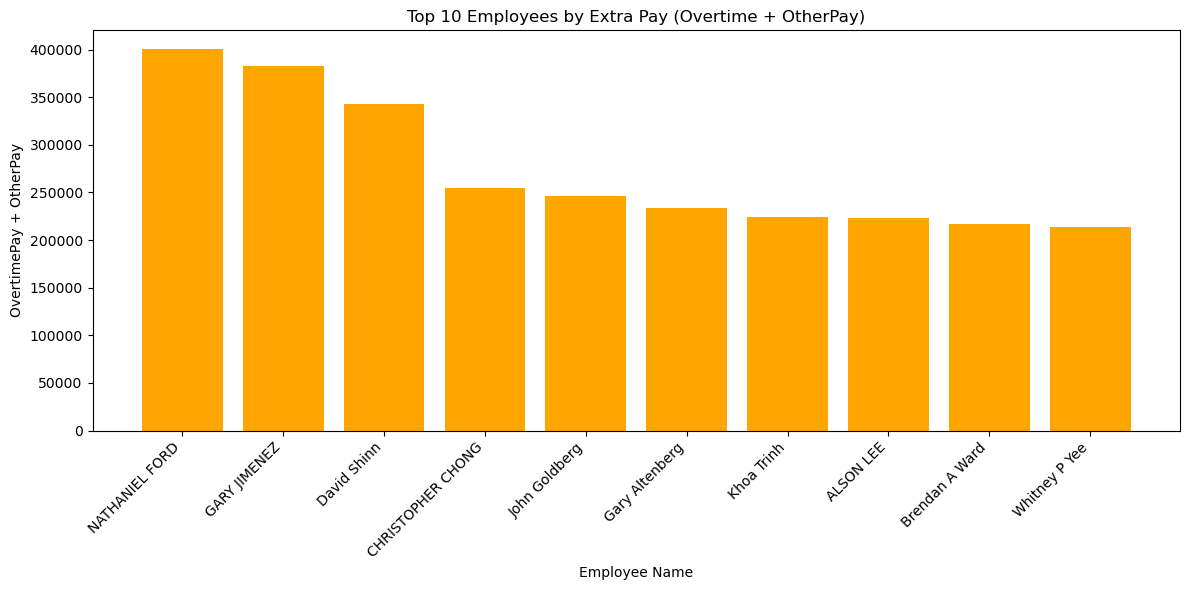

In [21]:
import matplotlib.pyplot as plt

# SQL query to get top 10 employees by (OvertimePay + OtherPay)
query = """
SELECT EmployeeName, (OvertimePay + OtherPay) AS ExtraPay
FROM Salaries
WHERE LOWER(EmployeeName) != 'not provided'
ORDER BY ExtraPay DESC
LIMIT 10;
"""

top_extra_pay = pd.read_sql_query(query, conn)

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(top_extra_pay['EmployeeName'], top_extra_pay['ExtraPay'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Employee Name")
plt.ylabel("OvertimePay + OtherPay")
plt.title("Top 10 Employees by Extra Pay (Overtime + OtherPay)")
plt.tight_layout()
plt.show()

8. Show The Average of BasePay, OverTime, OtherPay for all employees in pie chart? exclude ('Not Provided', 'Not provided')


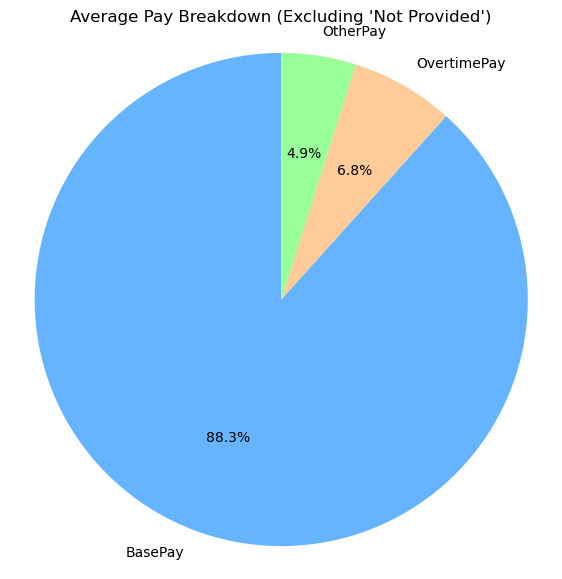

In [23]:
import matplotlib.pyplot as plt

# SQL query to calculate averages
query = """
SELECT 
    AVG(BasePay) AS AvgBasePay,
    AVG(OvertimePay) AS AvgOvertimePay,
    AVG(OtherPay) AS AvgOtherPay
FROM Salaries
WHERE LOWER(EmployeeName) != 'not provided';
"""

avg_pays = pd.read_sql_query(query, conn)

# Prepare data for pie chart
labels = ['BasePay', 'OvertimePay', 'OtherPay']
values = [
    avg_pays['AvgBasePay'][0],
    avg_pays['AvgOvertimePay'][0],
    avg_pays['AvgOtherPay'][0]
]

# Plotting the pie chart
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ffcc99', '#99ff99'])
plt.title("Average Pay Breakdown (Excluding 'Not Provided')")
plt.axis('equal')  # Equal aspect ratio ensures pie is circular.
plt.show()


9. Get the average TotalPayBenefits for each JobTitle, but only for those with an average pay greater than 75000? exclude ('Not Provided', 'Not provided')


In [33]:
query = """
SELECT JobTitle, ROUND(AVG(TotalPayBenefits), 2) AS AvgTotalPayBenefits
FROM Salaries
WHERE LOWER(JobTitle) != 'not provided'
  AND TotalPayBenefits IS NOT NULL
  AND TotalPayBenefits > 0
GROUP BY JobTitle
HAVING AvgTotalPayBenefits > 75000
ORDER BY AvgTotalPayBenefits DESC;
"""

high_avg_pay_titles = pd.read_sql_query(query, conn)
high_avg_pay_titles

,JobTitle,AvgTotalPayBenefits
0,Chief Investment Officer,436224.36
1,Chief of Police,411732.27
2,"Chief, Fire Department",408865.33
3,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.28
4,"Gen Mgr, Public Trnsp Dept",380696.44
...,...,...
1433,"OPERATING ENGINEER, UNIVERSAL",75273.75
1434,CABLE SPLICER,75255.01
1435,Community Development Asst,75246.66
1436,Senior Legal Process Clerk,75108.72


10. Get the number of employees (EmployeeName) for each JobTitle, where the count is greater than 10?  exclude ('Not Provided', 'Not provided')


In [27]:
query = """
SELECT JobTitle, COUNT(EmployeeName) AS EmployeeCount
FROM Salaries
WHERE LOWER(EmployeeName) != 'not provided'
GROUP BY JobTitle
HAVING EmployeeCount > 10
ORDER BY EmployeeCount DESC;
"""

jobtitle_counts = pd.read_sql_query(query, conn)
jobtitle_counts


,JobTitle,EmployeeCount
0,Transit Operator,7036
1,Special Nurse,4389
2,Registered Nurse,3736
3,Public Svc Aide-Public Works,2518
4,Police Officer 3,2421
...,...,...
1151,AUTOMOTIVE MECHANIC ASSISTANT SUPERVISOR,11
1152,ASSOCIATE PERFORMANCE AUDITOR,11
1153,ASSISTANT ELECTRONIC MAINTENANCE TECHNICIAN,11
1154,ARTS PROGRAM ASSISTANT,11
